## Exploring Mars -- Solution

We would like to scout some unexplored Martian terrain using a new advanced exploring vehicle
known as a crawler. There are spots we would like to slow down and analyze the terrain, and other
spots that are of "low interest" and we can go relatively quickly. Sometimes it is even desirable to
"backtrack" to view the area from another direction. To perform the analysis, we increase or decrease
the crawler speed by one mile per hour (mph) at a time (this can be negative!). There are 200 discrete
points we would like to change the crawler speed. The desired sequence of speeds is given by the plot
below:

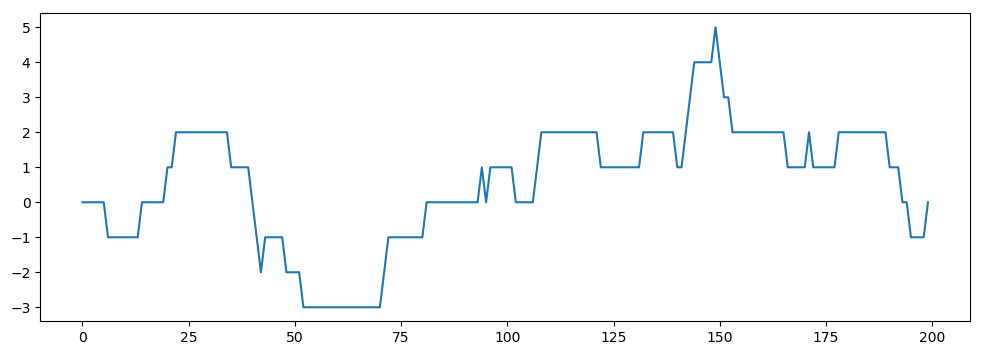

In [2]:
# set a seed so we get the same output every time
seed = 67348523
srand(seed)
# initialize the vector of speeds
val = 0
u = zeros(200)
u[1] = val
# set a density that determines how often the speed changes 
# low density corresponds to infrequent speed changes
dens = 0.09
# build speed vector for all times between now and time 199 
for i in 2:199
    # if a uniform(0,1) variable is < density
    if rand() < dens
        # increase the speed by 1 mph
        val = val + 1
        u[i] = val
    # if a uniform(0,1) variable is >= 1 - density
    elseif rand() >= 1.0-dens
        # decrease the speed by 1 mph
        val = val - 1
        u[i] = val
    else
        # otherwise the speed stays the same
        u[i] = val
    end
end

# the final speed must be 0
u[200] = 0

# T = 200
T = length(u)

# plot the speeds (your figure should match the one in the assignment!)
using PyPlot
figure(figsize=(12,4))
plot(u,"-");


Unfortunately, abrupt changes in speed cause undesirable wear on the crawler engines, so we would like to find an alternative sequence of speed changes with smoother transitions. If each speed is given by $u_1, u_2, \dotsm, u_200$, one way to characterize smoothness is via the sum of the squared differences between each successive speed:
\begin{align}
R(u) = (u_2 - u_1)^2 + (u_3 - u_2)^2 + \dotsm + (u_{200} - u_{199})^2.
\end{align}
Smaller values of $R(u)$ give smoother transitions. Solve a regularized least squares problem that explores the tradeoff between matching the desired speed curve perfectly and making the transitions smooth. Include a plot comparing the desired speeds to a few different smoothed versions obtained
using regularized least squares with regularization weights of 0.01 0.5 1 50, and 500.

In [3]:
using JuMP, Gurobi

function solveSpeed(λ)
    m = Model(solver=GurobiSolver(OutputFlag=0))

    @variable(m, x[1:T])    # resulting speed


    # constraint on start and end positions and velocities
    @constraint(m, x[1] == 0)
    @constraint(m, x[T] == 0)

    # min regularized objective (weighted sum of Ax-b and R(x))
    @objective(m, Min, sum((x - u).^2) + λ*sum((x[t+1]-x[t])^2 for t in 1:199))

    solve(m)
    uopt = getvalue(x);

    # get each objective component
    y1 = sum((getvalue(x) - u).^2)
    y2 = sum((getvalue(x[t+1])-getvalue(x[t]))^2 for t in 1:199)

    return (uopt, y1, y2)
end;
    

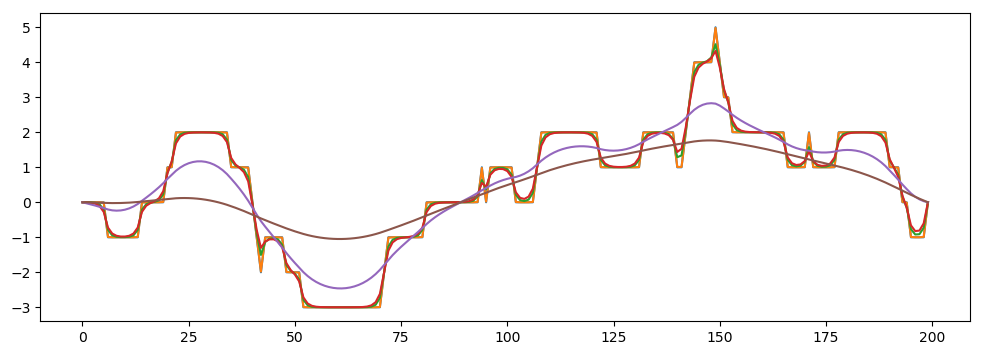

Academic license - for non-commercial use only
Academic license - for non-commercial use only
Academic license - for non-commercial use only
Academic license - for non-commercial use only
Academic license - for non-commercial use only


In [4]:
# create list of λ values
lambdas = [0.01 0.5 1 50 500]

# initialize list of objectives for each λ
J1 = zeros(length(lambdas))
J2 = zeros(length(lambdas))

# plot the desired speed
figure(figsize=(12,4))
plot(u,"-");

# for each λ
for i in 1:length(lambdas)
    # solve model with given λ
    (u2,J1[i],J2[i]) = solveSpeed(lambdas[i])
    # plot solution against desired speed
    plot(u2,"-");

end;


## Nonconvex quadratics -- Solution

Suppose you're presented with the constraint:

$x^2 + 2y^2 + 6z^2 + 4xy - 3xz - 6yz \leq 2$



###  (a) Write the constraint in the standard form $v^TQv \leq 1$ where Q is a symmetric matrix. What is Q and what is v?



Solution:

$Q = \begin{bmatrix}1 & 2 & -3/2 \\ 2 & 2 & -3\\ -3/2 & -3 & 6\end{bmatrix}$

$v = \begin{bmatrix} x\\ y \\ z\end{bmatrix}$


### (b)  It turns out the above constraint is not convex. In other words, the set of $(x, y, z)$ satisfying the constraint is not an ellipsoid. Explain why this is the case.

Note: you can perform an orthogonal decomposition of a symmetric matrix Q in Julia like this:

(L,U) = eig(Q) # L is the vector of eigenvalues and U is orthogonal

U * diagm(L) * U' # this is equal to Q (as long as Q was symmetric to begin with)


In [9]:
Q = [1 2 -3/2; 2 2 -3; -3/2 -3 6]
(L,U) = eig(Q);
println("L = ", L)
println("U = ", U)

L = [-0.668712, 1.34789, 8.32082]
U = [0.696603 -0.651382 -0.300743; -0.699814 -0.524505 -0.484928; -0.158132 -0.548266 0.821218]


Because the first eigenvalue ($\lambda_1$) is negative, $Q$ is indefinite. Thus, the quadratic fuction $x^TQx$ is not convex and the constraint does not describe an ellipsoid. 

### (c) We can write the constraint in norm format as follows: $\begin{align}
\|Av \|^2 - \|Bv\|^2 \leq 2
\end{align}$ What are $A$ and $B$ that make this constraint equivalent to the first constraint?


We first observe that we can rewrite the left-hand side as $(Av)^TAv - (Bv)^T(Bv)$, which simplifies to $v^T(A^TA - B^TB)v$. Thus, $Q = A^TA - B^TB$. We know 1) $Q$ can be written as the difference of two PSD matrices and 2) $Q = ULU^T$. Let $u_{ij}$ be the element in the $i$th row and $j$th column of $U$. Define the following:
* $P = \begin{bmatrix}u_{12} & u_{13}\\ u_{22} & u_{23} \\ u_{32} & u_{33}\end{bmatrix} *\begin{bmatrix}\lambda_2 & 0 \\ 0 & \lambda_3 \end{bmatrix}*\begin{bmatrix}u_{12} & u_{13}\\ u_{22} & u_{23} \\ u_{32} & u_{33}\end{bmatrix}^T $
* $R = \begin{bmatrix}u_{11} \\ u_{21} \\ u_{31}\end{bmatrix} *\begin{bmatrix}|\lambda_1|\end{bmatrix}*\begin{bmatrix}u_{11} \\ u_{21} \\ u_{31}\end{bmatrix} ^T$


In [20]:
P = U[:,2:3]*diagm(L[2:3])*U[:,2:3]'
println("A'A = ", P) # P is exactly A'A 
A = P^0.5; # A must be the matrix square root of A'A
println("A = P^0.5 = ", A)

R = U[:,1]*diagm(abs(L[1]))*U[:,1]'
println("B'B = ", R) # R is exactly B'B
B = R^0.5; # B must be the matrix square root of B'B
println("B = R^0.5 = ", B)
println()
println("Q = ", Q) # check that Q = P - R
println("P - R = ", P - R)

A'A = [1.3245 1.67401 -1.57366; 1.67401 2.32749 -2.926; -1.57366 -2.926 6.01672]
A = P^0.5 = [0.753505 0.817339 -0.297796; 0.817339 0.997719 -0.814868; -0.297796 -0.814868 2.29435]
B'B = [0.324496 -0.325992 -0.0736621; -0.325992 0.327495 0.0740017; -0.0736621 0.0740017 0.0167216]
B = R^0.5 = [0.396817 -0.398646 -0.0900792; -0.398646 0.400483 0.0904944; -0.0900792 0.0904944 0.0204484]

Q = [1.0 2.0 -1.5; 2.0 2.0 -3.0; -1.5 -3.0 6.0]
P - R = [1.0 2.0 -1.5; 2.0 2.0 -3.0; -1.5 -3.0 6.0]


So $A = \begin{bmatrix}1.32 & 1.67 & -1.57 \\ 1.67 & 2.33 & -2.93\\ -1.57 & -2.94 & 6.02\end{bmatrix}^{1/2}$ and $B = \begin{bmatrix}0.32 & -0.33 & -0.07 \\ -0.33 & 0.33 & 0.07\\ -0.07 & 0.07 & 0.02\end{bmatrix}^{1/2}$ 

### (d)  Explain how to find $(x,y,z)$ that satisfy the above constraint but make $x^2 + y^2 + z^2$ arbitrarily large.

Define $z = U^Tv$. Then we can write $v^TQv = \lambda_1z_1^2 + \lambda_2z_2^2 + \lambda_3z_3^2$. Let $z = \begin{bmatrix}a\\0\\0\end{bmatrix}$. We are guaranteed to have $v^TQv < 0$ for any $a > 0$ (so the constraint is satisfied for any positive $a$). Then $v = (U^T)^{-1}z = Uz = \begin{bmatrix}x \\ y \\ z\end{bmatrix} =\begin{bmatrix}u_{11}a \\ u_{21}a \\ u_{31}a\end{bmatrix}$. We conclude that $x^2 + y^2 + z^2 = a^2(u_{11}^2 + u_{21}^2 + u_{31}^2)$, so by making $a$ arbitrarily large we satisfy the constraint and make the sum $x^2 + y^2 + z^2$ arbitrarily large.